In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from psyduck import Spin, SpinSeries
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import zeeman_hamiltonian, quadrupole_hamiltonian, drive_hamiltonian
from psyduck.plotting import plot_populations

# NMR Rabi Oscillations with Cross-Driving

When driving a multi-level spin system ($I = 7/2$) with a tone resonant with one $\Delta m = 1$ transition, the same tone is also off-resonant for every other transition. This **cross-driving** (or cross-coupling) causes parasitic population transfer to neighbouring transitions.

The `drive_hamiltonian` function constructs the time-dependent Hamiltonian in the **generalised rotating frame (GRF)**, where each transition $k$ is in its own rotating frame at frequency $f_{\mathrm{rf},k}$. Cross-coupling is controlled via the `cross_coupling_cutoff` parameter:

- `cross_coupling_cutoff=None` — all tones reach all transitions (full cross-coupling)
- `cross_coupling_cutoff` $\ll f_q$ — each transition only sees its resonant tone (no cross-coupling)

The severity of cross-coupling is set by the ratio $\Omega_R / f_q$ where $\Omega_R$ is the Rabi frequency and $f_q$ is the quadrupole splitting (the spacing between consecutive transition frequencies). Cross-coupling is negligible when $\Omega_R \ll f_q$ and significant when $\Omega_R \sim f_q$.

In [2]:
# --- Physical parameters ---
I      = 7/2
gamma  = 5.55e6   # Hz/T  (^121Sb gyromagnetic ratio)
B0     = 1.0      # T
f_q    = 20e3     # Hz    (quadrupole splitting)

Ix, Iy, Iz = get_spin_operators(I)
d = int(2 * I + 1)   # Hilbert space dimension = 8

# Static lab-frame Hamiltonian
H_static = zeeman_hamiltonian(I, B0, gamma=gamma) + quadrupole_hamiltonian(I, f_q)

# NMR resonance frequencies — energy difference between adjacent eigenstates (ascending)
evals = H_static.eigenstates()[0]
resonance_frequencies = np.diff(evals)   # shape (7,), in Hz

print(f"{'k':>3}  {'transition':>20}  {'frequency (MHz)':>18}")
print("-" * 48)
for k, f in enumerate(resonance_frequencies):
    m_u = I - k
    print(f"{k:>3}  |{m_u:+.1f}⟩ ↔ |{m_u-1:+.1f}⟩       {f/1e6:>14.6f}")

print(f"\nLarmor frequency : {np.mean(resonance_frequencies)/1e6:.4f} MHz")
print(f"Transition spacing fq_1 : {np.mean(np.diff(resonance_frequencies))/1e3:.2f} kHz")

  k            transition     frequency (MHz)
------------------------------------------------
  0  |+3.5⟩ ↔ |+2.5⟩             5.490000
  1  |+2.5⟩ ↔ |+1.5⟩             5.510000
  2  |+1.5⟩ ↔ |+0.5⟩             5.530000
  3  |+0.5⟩ ↔ |-0.5⟩             5.550000
  4  |-0.5⟩ ↔ |-1.5⟩             5.570000
  5  |-1.5⟩ ↔ |-2.5⟩             5.590000
  6  |-2.5⟩ ↔ |-3.5⟩             5.610000

Larmor frequency : 5.5500 MHz
Transition spacing fq_1 : 20.00 kHz


## 1 — Single-tone selective drive

We drive only the **central transition** $k=3$ ($|{+1/2}\rangle \leftrightarrow |{-1/2}\rangle$) with a single RF tone at its resonance frequency $f_3$.

In the GRF of each transition $k$, this tone appears at detuning

$$\delta_k = f_3 - f_{\mathrm{rf},k} = (k-3)\,f_q$$

so transition 2 and 4 see the drive at $\pm f_q$, transitions 1 and 5 at $\pm 2f_q$, etc.

The maximum off-resonant population transfer to transition $k$ is

$$P_k^\mathrm{max} = \frac{\Omega_{R,k}^2}{\Omega_{R,k}^2 + \delta_k^2}$$

where $\Omega_{R,k} = \text{amplitude} \times |T_x^k|$ is the Rabi frequency via the transition matrix element. With `amplitude` $= 5$ kHz and $f_q = 20$ kHz, the nearest neighbours ($|\delta| = f_q$) receive up to $\sim 20\%$ of the population.

In [6]:
k_drive   = 3         # central transition |+1/2⟩ ↔ |-1/2⟩
amplitude = 3e3       # Hz  (Rabi frequency ≈ amplitude × 2 ≈ 10 kHz for central transition)

# Time array: show ~4 Rabi periods of the central transition
T_pi = 1 / (2 * amplitude * 2)    # central transition matrix element = 2
n_times = 4000
time_array = np.linspace(0, 8 * T_pi, n_times)

# Single drive tone at the resonance of transition k_drive
drive_amps = amplitude * np.ones((1, n_times), dtype=complex)
drive_freqs = np.array([resonance_frequencies[k_drive]])

H_no_cc = drive_hamiltonian(I, time_array, drive_amps, drive_freqs, resonance_frequencies,
                             cross_coupling_cutoff=0.5)   # only resonant transition sees the drive
H_cc    = drive_hamiltonian(I, time_array, drive_amps, drive_freqs, resonance_frequencies,
                             cross_coupling_cutoff=None)  # all transitions see the tone

H0 = 0 * qt.identity(d)
psi0 = qt.basis(d, k_drive)   # start in |m = +1/2⟩, upper level of central transition

nucleus = Spin(I)
nucleus.make_eigenstate(1/2)
series_no_cc = nucleus.evolve([H0, *H_no_cc], time_array)

nucleus.make_eigenstate(1/2)
series_cc = nucleus.evolve([H0, *H_cc], time_array)

(<Figure size 800x250 with 3 Axes>,
 array([<Axes: xlabel='Time', ylabel='State index'>,
        <Axes: xlabel='Time', ylabel='Population'>], dtype=object))

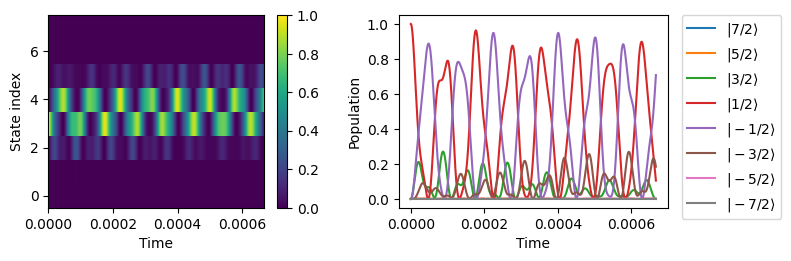

In [7]:
plot_populations(series_cc)

(<Figure size 800x250 with 3 Axes>,
 array([<Axes: xlabel='Time', ylabel='State index'>,
        <Axes: xlabel='Time', ylabel='Population'>], dtype=object))

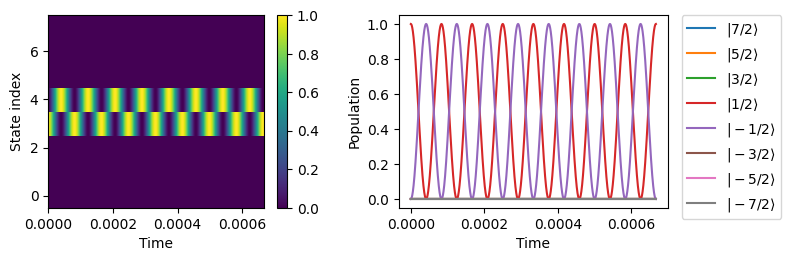

In [8]:
plot_populations(series_no_cc)

## 2 — Global NMR rotation

We now drive all seven transitions simultaneously at their resonance frequencies with equal amplitudes. 

In the absence of cross-coupling, the drive Hamiltonian in the GRF is time-independent:

$$H_\mathrm{GRF}^\mathrm{no\,CC} = 2\pi\,A \sum_k T_x^k = 2\pi\,A\, I_x$$

so the dynamics reduce to a clean global rotation around $I_x$, taking $\langle I_z \rangle$ from $+7/2$ toward $-7/2$.

With cross-coupling, each transition additionally sees six off-resonant tones oscillating in its rotating frame at $\pm f_q, \pm 2f_q, \pm 3f_q$, adding oscillatory perturbations on top of the smooth rotation.

In [9]:
amplitude_g = 3e3   # Hz — same as above for consistent comparison

n_times_g = 5000
T_pi = 1 / (2 * amplitude_g * 2)    # central transition matrix element = 2
time_array_g = np.linspace(0, 8 * T_pi, n_times_g)

# All 7 tones at equal real amplitude (→ Ix drive in the no-CC limit)
drive_amps_g  = amplitude_g * np.ones((d - 1, n_times_g), dtype=complex)
drive_freqs_g = resonance_frequencies   # drive at each transition's resonance

H_no_cc_g = drive_hamiltonian(I, time_array_g, drive_amps_g, drive_freqs_g, resonance_frequencies,
                               cross_coupling_cutoff=0.5)
H_cc_g    = drive_hamiltonian(I, time_array_g, drive_amps_g, drive_freqs_g, resonance_frequencies,
                               cross_coupling_cutoff=None)

spin_no_cc_g = Spin(I, qt.basis(d, 0))   # start in |m = +7/2⟩
series_no_cc_g = spin_no_cc_g.evolve([H0, *H_no_cc_g], time_array_g)

spin_cc_g = Spin(I, qt.basis(d, 0))
series_cc_g = spin_cc_g.evolve([H0, *H_cc_g], time_array_g)

(<Figure size 800x250 with 3 Axes>,
 array([<Axes: xlabel='Time', ylabel='State index'>,
        <Axes: xlabel='Time', ylabel='Population'>], dtype=object))

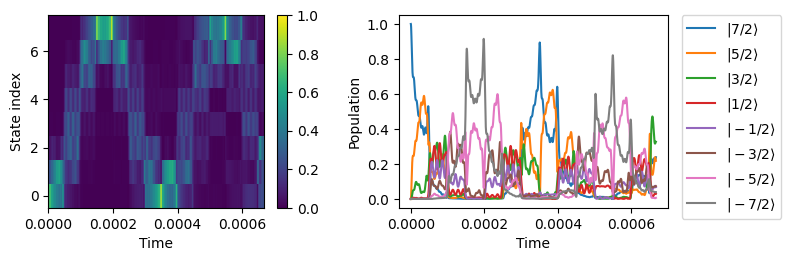

In [10]:
plot_populations(series_cc_g)

(<Figure size 800x250 with 3 Axes>,
 array([<Axes: xlabel='Time', ylabel='State index'>,
        <Axes: xlabel='Time', ylabel='Population'>], dtype=object))

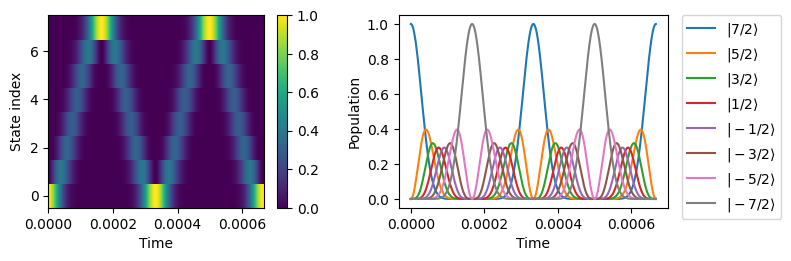

In [11]:
plot_populations(series_no_cc_g)

## 3 — Two-level rabi power sweep


In [ ]:
amplitudes = np.linspace(0.01 * f_q, 0.1 * f_q, 10)

n_times = 2
n_rabi_periods = 4   # simulate 4 full Rabi periods (2 pi-pulses) per amplitude

# Amplitudes must have shape (n_freqs, len(time_sweep))
drive_freqs_sw = np.array([resonance_frequencies[k_drive]])
psi0_sw        = qt.basis(d, k_drive)
H0_sw          = 0 * qt.identity(d)
Iz_populations = np.zeros((len(amplitudes), n_times))
state_fidelities = np.zeros_like(Iz_populations)

for idx, amp in enumerate(amplitudes):
    T_pi = 1 / (2 * amp * 2)   # T_pi per amplitude; central transition matrix element = 2
    time_array = np.linspace(0, T_pi, n_times, endpoint=True)   # normalized to T_pi

    amps = np.ones((1, n_times)) * amp
    H_sw = drive_hamiltonian(I, T_pi, amps, drive_freqs_sw,
                             resonance_frequencies)
    series_sw = Spin(I, psi0_sw).evolve([H0_sw, *H_sw], time_array)
    Iz_populations[idx] = series_sw.Iz()
    state_fidelities[idx] = series_sw.fidelity(qt.basis(d, k_drive + 1))   # target is |m = -1/2⟩


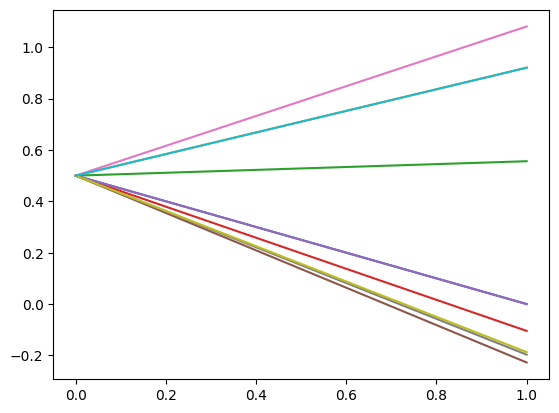

In [73]:
plt.plot(Iz_populations.T)

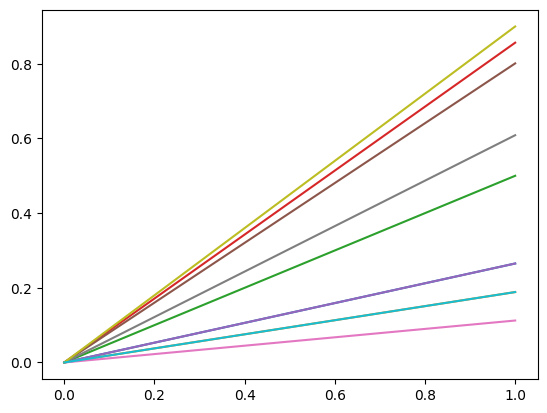

In [74]:
plt.plot(state_fidelities.T)